In [2]:
import torch
import gc
import contextlib
from tensordict import TensorDict
from torch.cuda import Stream 
from torch.utils.benchmark import Timer
import matplotlib.pyplot as plt
from torch.profiler import profile,ProfilerActivity
### Initialization 
# Create a custom CUDA stream for asynchronous operations
cuda_stream = torch.cuda.Stream()
torch.manual_seed(42)
# Define data size 
data_size = 1024**2 * 5
# Allocate pinned memory on CPU for faster Host-to-Device (H2D) transfers
tensor_cpu_pinned_1 = torch.randn(data_size, pin_memory=True)
tensor_cpu_pinned_2 = torch.randn(data_size, pin_memory=True)
# Allocate tensor directly on GPU
tensor_cuda_base = torch.randn(data_size, device="cuda:0")
assert torch.cuda.is_available()
device = torch.device("cuda", torch.cuda.current_device())


In [3]:
### Inner Computation Function 
def run_iteration(pinned: bool, streamed: bool):
    """
    Simulates a single iteration of data transfer and computation.
    """
    # Use the custom stream if 'streamed' is True, otherwise use default context
    stream_context = torch.cuda.stream(cuda_stream) if streamed else contextlib.nullcontext()
    
    with stream_context:
        if pinned:
            # Transfer pinned memory with non-blocking flag
            tensor_cuda_h2d = tensor_cpu_pinned_1.to(device, non_blocking=True)
        else:
            # Transfer regular (or other pinned) memory
            tensor_cuda_h2d = tensor_cpu_pinned_2.to(device, non_blocking=True)
            
        # Record an event in the custom stream to track H2D completion
        h2d_event = cuda_stream.record_event()

    # Parallel computation on the default stream
    tensor_cuda_result = tensor_cuda_base * tensor_cuda_base * tensor_cuda_base
    
    # Record an event in the current (default) stream
    default_stream_event = torch.cuda.current_stream().record_event()
    
    # Synchronize events to ensure all operations finish before next step
    h2d_event.synchronize()
    default_stream_event.synchronize()

In [4]:
### Benchmarking and Profiling

def benchmark_with_profiler(pinned: bool, streamed: bool) -> None:
    """
    Runs the iteration function through the PyTorch Profiler to analyze performance.
    """
    # Enable CUDA synchronization tracking in profiler
    torch._C._profiler._set_cuda_sync_enabled_val(True)
    
    wait, warmup, active = 1, 1, 2
    total_steps = wait + warmup + active
    rank = 0  # Simulation of distributed rank
    
    with torch.profiler.profile(
        activities=[
            torch.profiler.ProfilerActivity.CPU,
            torch.profiler.ProfilerActivity.CUDA,
        ],
        schedule=torch.profiler.schedule(
            wait=wait, 
            warmup=warmup, 
            active=active, 
            repeat=1, 
            skip_first=1
        ),
    ) as prof:
        for step_idx in range(1, total_steps + 1):
            run_iteration(pinned=pinned, streamed=streamed)
            
            # Advance the profiler state
            if rank == 0:
                prof.step()
                
    # Export the results for visualization in Chrome Trace (chrome://tracing)
    filename = f"trace_streamed{int(streamed)}_pinned{int(pinned)}.json"
    prof.export_chrome_trace(filename)
    print(f"Exported: {filename}")

### Execution
benchmark_with_profiler(pinned=False, streamed=False)
benchmark_with_profiler(pinned=True,  streamed=False)
benchmark_with_profiler(pinned=False, streamed=True)
benchmark_with_profiler(pinned=True,  streamed=True)

Exported: trace_streamed0_pinned0.json
Exported: trace_streamed0_pinned1.json
Exported: trace_streamed1_pinned0.json
Exported: trace_streamed1_pinned1.json


In [5]:
def timer(cmd):
    """
    Measures the median execution time of a command using adaptive autoranging.
    Results are printed and returned in milliseconds.
    """
    # adaptive_autorange ensures the command runs long enough to get a stable measurement
    timer_obj = Timer(cmd, globals=globals())
    result = timer_obj.adaptive_autorange(min_run_time=1.0, max_run_time=20.0)
    
    median_ms = result.median * 1000
    print(f"{cmd}: {median_ms: 4.4f} ms")
    
    return median_ms

def copy_to_device(*tensors):
    """
    Standard synchronous copy of tensors to the GPU.
    """
    results = []
    for tensor in tensors:
        results.append(tensor.to("cuda:0"))
    return results

def copy_to_device_nonblocking(*tensors):
    """
    Asynchronous copy of tensors to the GPU. 
    Note: This is most effective when tensors are in pinned memory.
    """
    results = []
    for tensor in tensors:
        results.append(tensor.to("cuda:0", non_blocking=True))
    
    # Explicitly wait for all kernels in all streams on the GPU to complete
    torch.cuda.synchronize()
    return results

pageable_tensor.to('cuda:0'):  3.7722 ms
pinned_tensor.to('cuda:0'):  3.5080 ms
pageable_tensor.pin_memory():  0.6912 ms
pageable_tensor.pin_memory().to('cuda:0'):  9.0685 ms


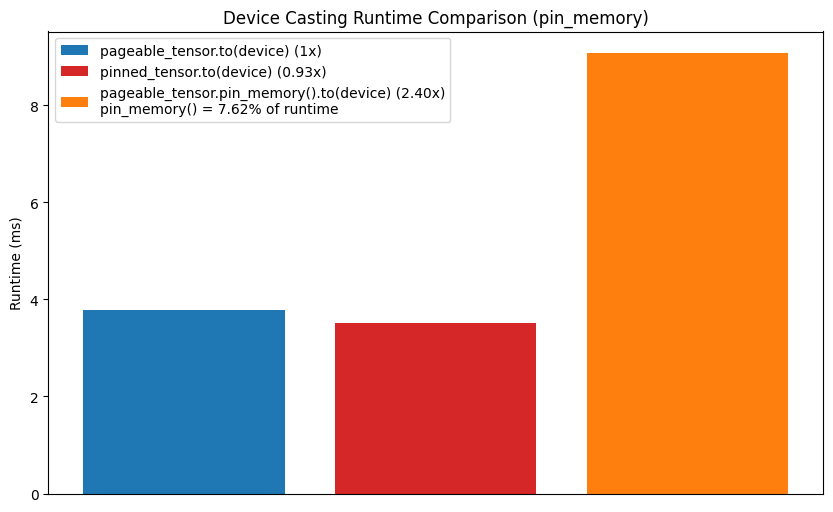

1682

In [6]:
### Data Preparation
pageable_tensor = torch.rand(1_000_000)
pinned_tensor = torch.rand(1_000_000, pin_memory=True)

### Performance Benchmarking

# Measure standard host-to-device transfer
time_pageable_to_device = timer("pageable_tensor.to('cuda:0')")

# Measure pinned memory host-to-device transfer
time_pinned_to_device = timer("pinned_tensor.to('cuda:0')")

# Measure time taken only to pin the memory on the CPU
time_pin_operation = timer("pageable_tensor.pin_memory()")

# Measure the full pipeline: pinning memory and then transferring to device
time_pin_and_transfer = timer("pageable_tensor.pin_memory().to('cuda:0')")

# Calculate performance ratios
ratio_pinned = time_pinned_to_device / time_pageable_to_device
ratio_pin_transfer = time_pin_and_transfer / time_pageable_to_device

### Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x_indices = [0, 1, 2]
values = [time_pageable_to_device, time_pinned_to_device, time_pin_and_transfer]
colors = ["tab:blue", "tab:red", "tab:orange"]
labels = [
    "pageable_tensor.to(device) (1x)",
    f"pinned_tensor.to(device) ({ratio_pinned:4.2f}x)",
    f"pageable_tensor.pin_memory().to(device) ({ratio_pin_transfer:4.2f}x)\n"
    f"pin_memory() = {100 * time_pin_operation / time_pin_and_transfer:.2f}% of runtime"
]


ax.bar(x_indices, values, label=labels, color=colors)
ax.set_ylabel("Runtime (ms)")
ax.set_title("Device Casting Runtime Comparison (pin_memory)")
ax.set_xticks([])
ax.legend()
plt.show()

### Cleanup 
del pageable_tensor, pinned_tensor
gc.collect()

copy_to_device(*tensors_list):  75.5242 ms
copy_to_device_nonblocking(*tensors_list):  47.8801 ms


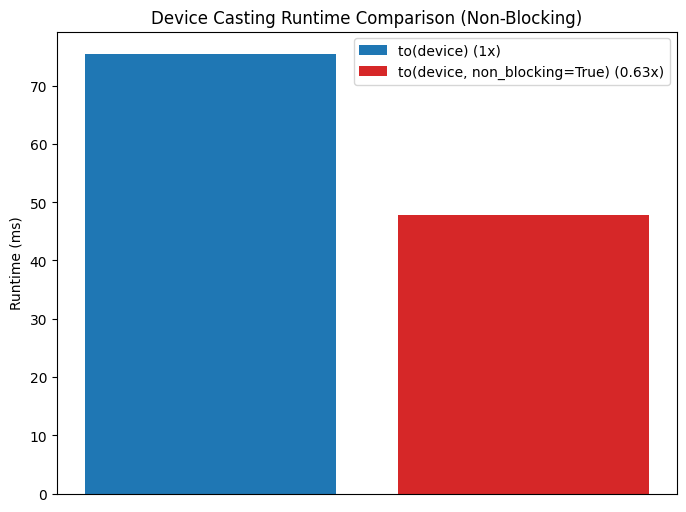

------------------------------
Profiling result for: copy_to_device(*tensors_list)
------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                            aten::to         3.40%       2.995ms        99.95%      88.031ms      88.031us       0.000us         0.00%      34.455ms      34.455us          1000  
                      aten::_to_copy         8.60%       7.576ms        96.55%      85.037ms      85.037us       0.000us         0.00%      34.455ms      34.455us          1000  
                     

In [7]:
### Performance Benchmarking: Blocking vs Non-Blocking

# Initialize a list of 1000 small tensors
tensors_list = [torch.randn(1000) for _ in range(1000)]

# Measure standard synchronous transfer
time_device = timer("copy_to_device(*tensors_list)")

# Measure non-blocking transfer (includes a manual synchronize at the end)
time_device_nonblocking = timer("copy_to_device_nonblocking(*tensors_list)")

# Calculate speed ratio
ratio_nonblocking = time_device_nonblocking / time_device

### Visualization
fig, ax = plt.subplots(figsize=(8, 6))

x_indices = [0, 1]
values = [time_device, time_device_nonblocking]
colors = ["tab:blue", "tab:red"]
labels = [
    f"to(device) (1x)",
    f"to(device, non_blocking=True) ({ratio_nonblocking:4.2f}x)"
]
ax.bar(x_indices, values, label=labels, color=colors)
ax.set_ylabel("Runtime (ms)")
ax.set_title("Device Casting Runtime Comparison (Non-Blocking)")
ax.set_xticks([])
ax.legend()
plt.show()

### Memory Profiling
def profile_performance(command):
    """
    Runs the PyTorch Profiler on a specific command to inspect CPU and CUDA activity.
    """
    with torch.profiler.profile(
        activities=[
            torch.profiler.ProfilerActivity.CPU,
            torch.profiler.ProfilerActivity.CUDA
        ]
    ) as prof:
        # Using a dictionary for exec scope to access global/local variables
        exec(command, globals(), locals())
    
    print("-" * 30)
    print(f"Profiling result for: {command}")
    print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

profile_performance("copy_to_device(*tensors_list)")
profile_performance("copy_to_device_nonblocking(*tensors_list)")

In [8]:
### Advanced Performance Comparison: Pinning vs. Non-Blocking

def pin_copy_to_device(*tensors):
    """Pins memory and copies to device synchronously."""
    results = []
    for tensor in tensors:
        results.append(tensor.pin_memory().to("cuda:0"))
    return results

def pin_copy_to_device_nonblocking(*tensors):
    """Pins memory and copies to device asynchronously."""
    results = []
    for tensor in tensors:
        results.append(tensor.pin_memory().to("cuda:0", non_blocking=True))
    torch.cuda.synchronize()
    return results

copy_to_device(*tensors_pageable):  134.5088 ms
copy_to_device_nonblocking(*tensors_pageable):  88.6877 ms
copy_to_device(*tensors_pinned):  133.0896 ms
copy_to_device_nonblocking(*tensors_pinned):  78.7811 ms
pin_copy_to_device(*tensors_pageable):  158.9075 ms
pin_copy_to_device_nonblocking(*tensors_pageable):  84.7124 ms


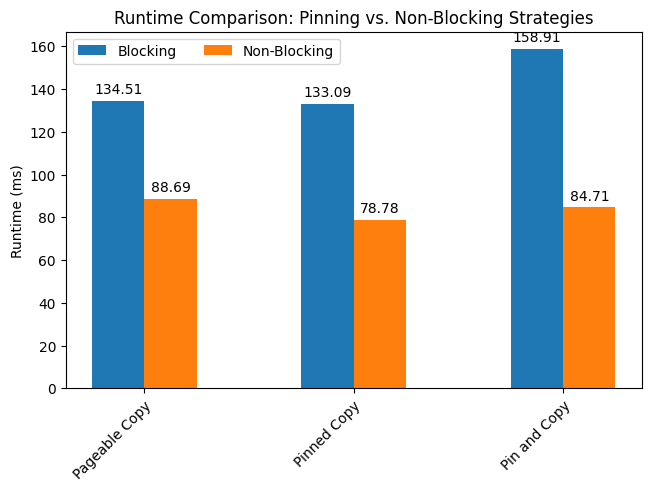

51740

In [ ]:
### Initialize datasets
tensors_pageable = [torch.randn(10_000) for _ in range(1000)]
tensors_pinned = [torch.rand(10_000, pin_memory=True) for _ in range(1000)]

### Measure Strategies
# Pageable Copy
time_pageable = timer("copy_to_device(*tensors_pageable)")
time_pageable_nb = timer("copy_to_device_nonblocking(*tensors_pageable)")
# Pinned Copy (Pre-pinned)
time_pinned = timer("copy_to_device(*tensors_pinned)")
time_pinned_nb = timer("copy_to_device_nonblocking(*tensors_pinned)")
# Pin-on-the-fly and Copy
time_pin_and_copy = timer("pin_copy_to_device(*tensors_pageable)")
time_pin_and_copy_nb = timer("pin_copy_to_device_nonblocking(*tensors_pageable)")

### Visualization
strategies = ("Pageable Copy", "Pinned Copy", "Pin and Copy")
data = {
    "Blocking": [time_pageable, time_pinned, time_pin_and_copy],
    "Non-Blocking": [time_pageable_nb, time_pinned_nb, time_pin_and_copy_nb]
}
x_indices = torch.arange(len(strategies))
width = 0.25
multiplier = 0
fig, ax = plt.subplots(layout="constrained")
for label, runtimes in data.items():
    offset = width * multiplier
    rects = ax.bar(x_indices + offset, runtimes, width, label=label)
    ax.bar_label(rects, padding=3, fmt="%.2f")
    multiplier += 1

ax.set_ylabel("Runtime (ms)")
ax.set_title("Runtime Comparison: Pinning vs. Non-Blocking Strategies")
ax.set_xticks(x_indices + width / 2)
ax.set_xticklabels(strategies)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.legend(loc="upper left", ncols=2)
plt.show()

## Cleanup
del tensors_pageable, tensors_pinned
gc.collect()

In [10]:
### Safety and Integrity Test: Data Race Verificatio

# Sleep duration 
delay_cycles = 100000000

## Test 1: Non-blocking transfer with PINNED memory
try:
    for i in range(100):
        cpu_pinned = torch.ones(1024, 1024, pin_memory=True)
        torch.cuda.synchronize()
        
        # Start asynchronous copy
        gpu_tensor = cpu_pinned.to("cuda", non_blocking=True)
        
        # Force GPU to wait, giving CPU time to modify memory
        torch.cuda._sleep(delay_cycles)
        
        # Modify CPU memory immediately
        cpu_pinned.zero_()
        
        # Verify if GPU tensor remained "1s" or was corrupted by "0s"
        assert (gpu_tensor == 1).all()
        
    print("No test failed with non-blocking and PINNED tensor.")
except AssertionError:
    print(f"Test failed at iteration {i} with non-blocking and PINNED tensor.")

## Test 2: Non-blocking transfer with PAGEABLE memory
try:
    for i in range(100):
        cpu_pageable = torch.ones(1024, 1024)
        torch.cuda.synchronize()
        
        # Attempt asynchronous copy (will fall back to synchronous)
        gpu_tensor = cpu_pageable.to("cuda", non_blocking=True)
        
        torch.cuda._sleep(delay_cycles)
        
        # Modify CPU memory
        cpu_pageable.zero_()
        
        assert (gpu_tensor == 1).all()
        
    print("No test failed with non-blocking and PAGEABLE tensor.")
except AssertionError:
    print(f"Test failed at iteration {i} with non-blocking and PAGEABLE tensor.")

Test failed at iteration 1 with non-blocking and PINNED tensor.
No test failed with non-blocking and PAGEABLE tensor.


In [11]:
### Device-to-Host (D2H) Asynchronous Transfer Test

# Initialize a large tensor on the GPU 
tensor_gpu = (torch.arange(1, 1_000_000, dtype=torch.double, device="cuda")
              .expand(100, 999999)
              .clone())

# Verify initial mean on GPU
torch.testing.assert_close(tensor_gpu.mean(), torch.tensor(500000.0, dtype=torch.double, device="cuda"))

## Test 1: Non-blocking transfer WITHOUT synchronization
try:
    for i in range(100):
        cpu_tensor = tensor_gpu.to("cpu", non_blocking=True)
        torch.testing.assert_close(cpu_tensor.mean(), torch.tensor(500000.0, dtype=torch.double))
    print("No test failed with non-blocking (Unexpected)")
except AssertionError:
    print(f"Iteration {i}: Test failed as expected. CPU accessed data before GPU finish copying.")

## Test 2: Non-blocking transfer WITH synchronization
try:
    for i in range(100):
        cpu_tensor = tensor_gpu.to("cpu", non_blocking=True)
        torch.cuda.synchronize()
        torch.testing.assert_close(cpu_tensor.mean(), torch.tensor(500000.0, dtype=torch.double))
    print("No test failed with non-blocking + synchronization.")
except AssertionError:
    print(f"Iteration {i}: Test failed unexpectedly.")

Iteration 0: Test failed as expected. CPU accessed data before GPU finish copying.
No test failed with non-blocking + synchronization.


td.to('cuda:0', non_blocking=False):  1097.7454 ms
td.to('cuda:0'):  821.5090 ms
td.to('cuda:0', non_blocking_pin=True, num_threads=0):  817.7129 ms
td.to('cuda:0', non_blocking_pin=True, num_threads=4):  822.3384 ms


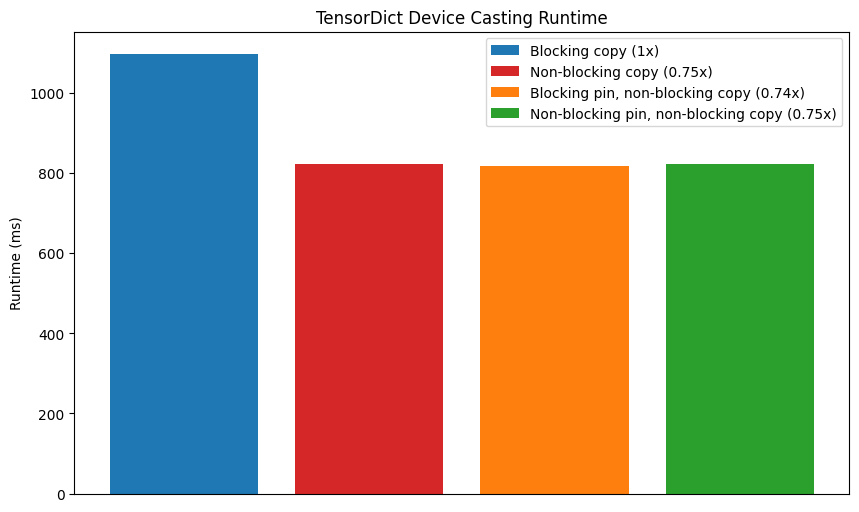

In [12]:
### Setup TensorDict
td = TensorDict({str(i): torch.randn(100_000) for i in range(1000)})

### Benchmarking TensorDict Transfers

# Standard synchronous transfer
time_blocking = timer("td.to('cuda:0', non_blocking=False)")

# Standard non-blocking transfer
time_non_blocking = timer("td.to('cuda:0')")

# Pinning memory on-the-fly (single-threaded) then non-blocking transfer
time_pin_non_blocking = timer("td.to('cuda:0', non_blocking_pin=True, num_threads=0)")

# Pinning memory on-the-fly (multi-threaded) then non-blocking transfer
time_multi_pin_non_blocking = timer("td.to('cuda:0', non_blocking_pin=True, num_threads=4)")

### Calculations and Ratios
ratio_nb = time_non_blocking / time_blocking
ratio_pin_nb = time_pin_non_blocking / time_blocking
ratio_multi_pin_nb = time_multi_pin_non_blocking / time_blocking

### Visualization
fig, ax = plt.subplots(figsize=(10, 6))
indices = [0, 1, 2, 3]
values = [time_blocking, time_non_blocking, time_pin_non_blocking, time_multi_pin_non_blocking]
colors = ["tab:blue", "tab:red", "tab:orange", "tab:green"]
labels = [
    f"Blocking copy (1x)",
    f"Non-blocking copy ({ratio_nb:4.2f}x)",
    f"Blocking pin, non-blocking copy ({ratio_pin_nb:4.2f}x)",
    f"Non-blocking pin, non-blocking copy ({ratio_multi_pin_nb:4.2f}x)"
]
ax.bar(indices, values, label=labels, color=colors)
ax.set_ylabel("Runtime (ms)")
ax.set_title("TensorDict Device Casting Runtime")
ax.set_xticks([])
ax.legend()
plt.show()